In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder


In [2]:
data = pd.read_csv("../data/survey_results.csv")

data.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
4,R00005,23,M,Metro,Student,NaN,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100


### 1. Data Cleaning 

In [3]:
data.duplicated().sum()

np.int64(10)

In [4]:
data[data.duplicated(keep= "first")]

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
2309,R02309,27,M,Urban,Working Professional,16L - 25L,3-4 times,Newcomer,Small (250 ml),2 to 4,Brand Reputation,Traditional,Online,Simple,Medium (Moderately health-conscious),Social (eg. Parties),150-200
2666,R02665,61,M,Metro,Entrepreneur,16L - 25L,3-4 times,Established,Medium (500 ml),above 4,Brand Reputation,Exotic,Retail Store,Simple,High (Very health-conscious),"Active (eg. Sports, gym)",200-250
5151,R05149,21,M,Semi-Urban,Student,NaN,3-4 times,Established,Small (250 ml),2 to 4,Availability,Traditional,Retail Store,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
7794,R07791,25,M,Metro,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
8516,R08512,20,F,Metro,Student,NaN,5-7 times,Established,Large (1 L),0 to 1,Price,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
11317,R11312,18,F,Urban,Student,NaN,0-2 times,Newcomer,Medium (500 ml),2 to 4,Availability,Exotic,Online,Premium,Medium (Moderately health-conscious),Social (eg. Parties),100-150
19050,R19044,57,M,Semi-Urban,Retired,<10L,3-4 times,Newcomer,Large (1 L),2 to 4,Price,Traditional,Retail Store,Premium,High (Very health-conscious),Social (eg. Parties),150-200
22412,R22405,26,M,Metro,Working Professional,16L - 25L,0-2 times,Newcomer,Small (250 ml),0 to 1,Price,Exotic,Online,Premium,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
23406,R23398,27,M,Urban,Working Professional,10L - 15L,5-7 times,Newcomer,Large (1 L),above 4,Availability,Traditional,Online,Premium,High (Very health-conscious),Casual (eg. At home),200-250
25068,R25059,34,F,Urban,Working Professional,16L - 25L,0-2 times,Newcomer,Small (250 ml),2 to 4,Brand Reputation,Exotic,Online,Eco-Friendly,High (Very health-conscious),"Active (eg. Sports, gym)",150-200


In [5]:
data.drop_duplicates(inplace= True)

In [6]:
data.duplicated().sum()

np.int64(0)

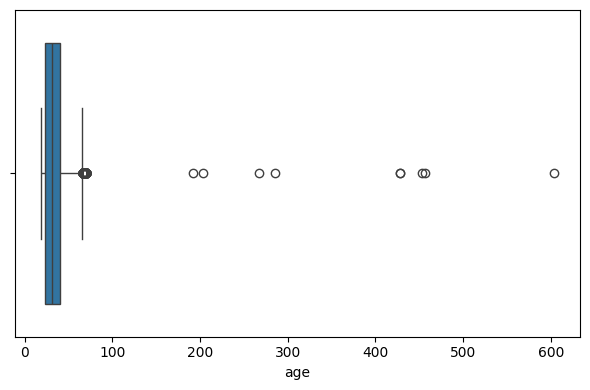

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(data= data, x = "age")
plt.tight_layout()
plt.show()

In [8]:
data["age"].describe()

count    30000.000000
mean        33.048167
std         13.438904
min         18.000000
25%         23.000000
50%         31.000000
75%         40.000000
max        604.000000
Name: age, dtype: float64

In [9]:
thres = data["age"].quantile(0.9997)

thres

np.float64(70.03659999996307)

In [10]:
df = data[data["age"] < 100].copy()

df.head()


,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
4,R00005,23,M,Metro,Student,NaN,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100


In [11]:
df.isna().sum()

respondent_id                        0
age                                  0
gender                               0
zone                                 0
occupation                           0
income_levels                     8060
consume_frequency(weekly)            8
current_brand                        0
preferable_consumption_size          0
awareness_of_other_brands            0
reasons_for_choosing_brands          0
flavor_preference                    0
purchase_channel                    10
packaging_preference                 0
health_concerns                      0
typical_consumption_situations       0
price_range                          0
dtype: int64

In [12]:
df[df["income_levels"].isna()]["occupation"].value_counts()

occupation
Student    8060
Name: count, dtype: int64

In [13]:
df["income_levels"].unique()

array(['<10L', '> 35L', '16L - 25L', nan, '10L - 15L', '26L - 35L'],
      dtype=object)

In [14]:
df["income_levels"] = df["income_levels"].fillna("not reported")

In [15]:
df["income_levels"].unique()

array(['<10L', '> 35L', '16L - 25L', 'not reported', '10L - 15L',
       '26L - 35L'], dtype=object)

In [16]:
df["consume_frequency(weekly)"].unique()

array(['3-4 times', '5-7 times', '0-2 times', nan], dtype=object)

In [17]:
df["purchase_channel"].unique()

array(['Online', 'Retail Store', nan], dtype=object)

In [18]:
df["consume_frequency(weekly)"].mode()[0]

'3-4 times'

In [19]:
df["consume_frequency(weekly)"] = df["consume_frequency(weekly)"].fillna(df["consume_frequency(weekly)"].mode()[0])

In [20]:
df["purchase_channel"].mode()[0]

'Online'

In [21]:
df["purchase_channel"] = df["purchase_channel"].fillna(df["purchase_channel"].mode()[0])

In [22]:
df.isna().sum()

respondent_id                     0
age                               0
gender                            0
zone                              0
occupation                        0
income_levels                     0
consume_frequency(weekly)         0
current_brand                     0
preferable_consumption_size       0
awareness_of_other_brands         0
reasons_for_choosing_brands       0
flavor_preference                 0
purchase_channel                  0
packaging_preference              0
health_concerns                   0
typical_consumption_situations    0
price_range                       0
dtype: int64

In [23]:
df["zone"].unique()

array(['Urban', 'Metro', 'Rural', 'Semi-Urban', 'Metor', 'urbna'],
      dtype=object)

In [24]:
len(df[df["zone"] == "Metor"])

4

In [25]:
df["current_brand"].unique()

array(['Newcomer', 'Established', 'newcomer', 'Establishd'], dtype=object)

In [26]:
df["zone"] = df["zone"].replace({
    'urbna': 'Urban',
    'Metor': 'Metro'

})

In [27]:
df["zone"].unique()

array(['Urban', 'Metro', 'Rural', 'Semi-Urban'], dtype=object)

In [28]:
df["current_brand"] = df["current_brand"].replace({
    'Establishd': 'Established',
    'newcomer': 'Newcomer'
})

In [29]:
df["current_brand"].unique()

array(['Newcomer', 'Established'], dtype=object)

### 2. Feature Engineering

In [30]:
bins = [18, 26, 36, 46, 56, 71, 101]

labels = ["18-25", "26-35", "36-45", "46-55", "56-70", "70+"]

df['age_group'] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels,
    right=False
)


In [31]:
df.head(2)

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55


In [32]:
df["age_group"].unique()

['26-35', '46-55', '36-45', '18-25', '56-70']
Categories (6, object): ['18-25' < '26-35' < '36-45' < '46-55' < '56-70' < '70+']

In [33]:
df["consume_frequency(weekly)"].unique()

array(['3-4 times', '5-7 times', '0-2 times'], dtype=object)

In [34]:
df["consume_frequency(weekly)"] = df["consume_frequency(weekly)"].map({
    '0-2 times': 1,
    '3-4 times': 2,
    '5-7 times': 3
})


In [35]:
df["awareness_of_other_brands"].unique()

array(['0 to 1', '2 to 4', 'above 4'], dtype=object)

In [36]:
df["awareness_of_other_brands"] = df["awareness_of_other_brands"].map({
    '0 to 1': 1,
    '2 to 4': 2,
    'above 4': 3
})

df.head(2)

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group
0,R00001,30,M,Urban,Working Professional,<10L,2,Newcomer,Medium (500 ml),1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35
1,R00002,46,F,Metro,Working Professional,> 35L,3,Established,Medium (500 ml),2,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55


In [37]:
df["cf_ab_score"] = (
    df["consume_frequency(weekly)"] / (df["consume_frequency(weekly)"] + df["awareness_of_other_brands"])
).round(2)

In [38]:
df["cf_ab_score"].describe()

count    29991.000000
mean         0.537350
std          0.141866
min          0.250000
25%          0.500000
50%          0.500000
75%          0.670000
max          0.750000
Name: cf_ab_score, dtype: float64

In [39]:
df["zone"].unique()

array(['Urban', 'Metro', 'Rural', 'Semi-Urban'], dtype=object)

In [40]:
df["zone"] = df["zone"].map({
    'Rural': 1,
    'Semi-Urban': 2,
    'Urban': 3,
    'Metro': 4
})

In [41]:
df["income_levels"].unique()

array(['<10L', '> 35L', '16L - 25L', 'not reported', '10L - 15L',
       '26L - 35L'], dtype=object)

In [42]:
df["income_levels"] = df["income_levels"].map({
    'not reported': 0,
    '<10L': 1,
    '10L - 15L': 2,
    '16L - 25L': 3,
    '26L - 35L': 4,
    '> 35L': 5
})

In [43]:
df.head(2)

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score
0,R00001,30,M,3,Working Professional,1,2,Newcomer,Medium (500 ml),1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35,0.67
1,R00002,46,F,4,Working Professional,5,3,Established,Medium (500 ml),2,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55,0.60


In [44]:
df['zas_score'] = df["zone"] * df["income_levels"]

df.head(2)

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score,zas_score
0,R00001,30,M,3,Working Professional,1,2,Newcomer,Medium (500 ml),1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35,0.67,3
1,R00002,46,F,4,Working Professional,5,3,Established,Medium (500 ml),2,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55,0.60,20


In [45]:
len(df["zas_score"].unique())

14

In [46]:
df['bsi'] = np.where(
    (df["current_brand"] != "Established") & 
    (df["reasons_for_choosing_brands"].isin(["Price", "Quality"])),
    1, 0
)

df.head(2)

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,...,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_ab_score,zas_score,bsi
0,R00001,30,M,3,Working Professional,1,2,Newcomer,Medium (500 ml),1,...,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35,0.67,3,1
1,R00002,46,F,4,Working Professional,5,3,Established,Medium (500 ml),2,...,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55,0.60,20,0


In [47]:
df.shape

(29991, 21)

In [48]:
pd.crosstab(df["age_group"], df["occupation"])

occupation,Entrepreneur,Retired,Student,Working Professional
age_group,,,,
18-25,535,0,7328,2605
26-35,1826,0,697,6570
36-45,1619,0,0,4353
46-55,799,0,0,2167
56-70,221,1130,35,106


In [49]:
mask = (df["age_group"] =="56-70") & (df["occupation"] == "Student")

df = df[~mask]

pd.crosstab(df["age_group"], df["occupation"])

occupation,Entrepreneur,Retired,Student,Working Professional
age_group,,,,
18-25,535,0,7328,2605
26-35,1826,0,697,6570
36-45,1619,0,0,4353
46-55,799,0,0,2167
56-70,221,1130,0,106


In [50]:
df.shape

(29956, 21)

In [51]:
df["bsi"].value_counts()

bsi
0    20796
1     9160
Name: count, dtype: int64

### 3. Predictive Modeling

In [52]:
df.columns

Index(['respondent_id', 'age', 'gender', 'zone', 'occupation', 'income_levels',
       'consume_frequency(weekly)', 'current_brand',
       'preferable_consumption_size', 'awareness_of_other_brands',
       'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel',
       'packaging_preference', 'health_concerns',
       'typical_consumption_situations', 'price_range', 'age_group',
       'cf_ab_score', 'zas_score', 'bsi'],
      dtype='object')

In [53]:
X = df.drop(columns=["respondent_id", "price_range", "age"])
y = df["price_range"]

In [54]:
y

0        100-150
1        200-250
2        200-250
3        150-200
4         50-100
          ...   
30005    150-200
30006    200-250
30007    150-200
30008    150-200
30009    150-200
Name: price_range, Length: 29956, dtype: object

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state= 42)

In [56]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [57]:
X["age_group"].value_counts()

age_group
18-25    10468
26-35     9093
36-45     5972
46-55     2966
56-70     1457
70+          0
Name: count, dtype: int64

In [58]:
X["health_concerns"].value_counts()

health_concerns
High (Very health-conscious)            11893
Medium (Moderately health-conscious)    10624
Low (Not very concerned)                 7439
Name: count, dtype: int64

In [59]:
X["preferable_consumption_size"].value_counts()

preferable_consumption_size
Medium (500 ml)    13205
Small (250 ml)      9709
Large (1 L)         7042
Name: count, dtype: int64

In [60]:
X.select_dtypes('object').columns

Index(['gender', 'occupation', 'current_brand', 'preferable_consumption_size',
       'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel',
       'packaging_preference', 'health_concerns',
       'typical_consumption_situations'],
      dtype='object')

In [61]:
X["income_levels"].value_counts()

income_levels
0    8025
3    5897
2    5251
1    4661
4    3872
5    2250
Name: count, dtype: int64

In [62]:
X.select_dtypes('object').columns

Index(['gender', 'occupation', 'current_brand', 'preferable_consumption_size',
       'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel',
       'packaging_preference', 'health_concerns',
       'typical_consumption_situations'],
      dtype='object')

In [63]:
ct = ColumnTransformer(transformers=[

    ('oe', OrdinalEncoder(categories=[
        ["18-25", "26-35", "36-45", "46-55", "56-70", "70+"],
        ["Low (Not very concerned)", 
         "Medium (Moderately health-conscious)", 
         "High (Very health-conscious)"],
        ["Small (250 ml)", "Medium (500 ml)", "Large (1 L)"]
    ]),
     ["age_group", "health_concerns", "preferable_consumption_size"]
    ),

    ('one', OneHotEncoder(drop= 'first'),
     ["gender", "occupation", "current_brand", "reasons_for_choosing_brands", "flavor_preference", "purchase_channel", "packaging_preference", "typical_consumption_situations"]
    )
], remainder='passthrough', verbose_feature_names_out= False)

In [64]:
X_trian_transformed = pd.DataFrame(ct.fit_transform(X_train), columns= ct.get_feature_names_out())
X_test_transformed = pd.DataFrame(ct.transform(X_test), columns= ct.get_feature_names_out())

In [65]:
X_trian_transformed.head()

,age_group,health_concerns,preferable_consumption_size,gender_M,occupation_Retired,occupation_Student,occupation_Working Professional,current_brand_Newcomer,reasons_for_choosing_brands_Brand Reputation,reasons_for_choosing_brands_Price,...,packaging_preference_Simple,typical_consumption_situations_Casual (eg. At home),typical_consumption_situations_Social (eg. Parties),zone,income_levels,consume_frequency(weekly),awareness_of_other_brands,cf_ab_score,zas_score,bsi
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,1.0,2.0,2.0,1.0,3.0,0.25,4.0,0.0
1,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,3.0,3.0,3.0,2.0,0.60,9.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,3.0,0.0,2.0,2.0,0.50,0.0,1.0
3,1.0,0.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,4.0,3.0,2.0,2.0,0.50,12.0,0.0
4,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,4.0,3.0,1.0,3.0,0.25,12.0,0.0


In [66]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_trian_transformed, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [67]:
y_pred = gnb.predict(X_test_transformed)

In [68]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_score(y_test, y_pred)

0.5693684069969288

In [69]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.46      0.26      0.33      1930
           1       0.59      0.34      0.43      2223
           2       0.70      0.89      0.78      2430
           3       0.42      0.92      0.58       906

    accuracy                           0.57      7489
   macro avg       0.54      0.60      0.53      7489
weighted avg       0.57      0.57      0.54      7489



In [70]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter= 1000)
logreg.fit(X_trian_transformed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [71]:
y_pred = logreg.predict(X_test_transformed)

In [72]:
accuracy_score(y_test, y_pred)

0.8340232340766457

In [73]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.82      0.80      1930
           1       0.80      0.79      0.79      2223
           2       0.91      0.91      0.91      2430
           3       0.85      0.78      0.82       906

    accuracy                           0.83      7489
   macro avg       0.83      0.82      0.83      7489
weighted avg       0.83      0.83      0.83      7489



In [74]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_trian_transformed, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [75]:
y_pred = svc.predict(X_test_transformed)

In [76]:
accuracy_score(y_test, y_pred)

0.8419014554680198

In [77]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.82      0.80      1930
           1       0.80      0.82      0.81      2223
           2       0.92      0.91      0.92      2430
           3       0.85      0.77      0.81       906

    accuracy                           0.84      7489
   macro avg       0.84      0.83      0.83      7489
weighted avg       0.84      0.84      0.84      7489



In [78]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()
rfc.fit(X_trian_transformed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [79]:
y_pred = rfc.predict(X_test_transformed)

In [80]:
accuracy_score(y_test, y_pred)

0.8989184136733877

In [81]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      1930
           1       0.85      0.89      0.87      2223
           2       0.94      0.93      0.94      2430
           3       0.92      0.88      0.90       906

    accuracy                           0.90      7489
   macro avg       0.90      0.89      0.90      7489
weighted avg       0.90      0.90      0.90      7489



In [82]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_trian_transformed, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [83]:
y_pred = xgb.predict(X_test_transformed)

In [84]:
accuracy_score(y_test, y_pred)

0.9238883696087595

In [85]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      1930
           1       0.90      0.91      0.91      2223
           2       0.96      0.95      0.95      2430
           3       0.92      0.92      0.92       906

    accuracy                           0.92      7489
   macro avg       0.92      0.92      0.92      7489
weighted avg       0.92      0.92      0.92      7489



In [86]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()
lgbm.fit(X_trian_transformed, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000278 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 82
[LightGBM] [Info] Number of data points in the train set: 22467, number of used features: 24
[LightGBM] [Info] Start training from score -1.343386
[LightGBM] [Info] Start training from score -1.228925
[LightGBM] [Info] Start training from score -1.126779
[LightGBM] [Info] Start training from score -2.100810


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [87]:
y_pred = lgbm.predict(X_test_transformed)

In [88]:
accuracy_score(y_test, y_pred)

0.9268260114835092

In [89]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      1930
           1       0.90      0.92      0.91      2223
           2       0.96      0.96      0.96      2430
           3       0.93      0.92      0.92       906

    accuracy                           0.93      7489
   macro avg       0.93      0.92      0.92      7489
weighted avg       0.93      0.93      0.93      7489



In [ ]:
import mlflow
import dagshub
from sklearn.pipeline import Pipeline
import pandas as pd
import mlflow.sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

dagshub.init(repo_owner='Sharanch3', repo_name='beverage_price_predictor', mlflow=True)



mlflow.set_tracking_uri("https://dagshub.com/Sharanch3/beverage_price_predictor.mlflow")
mlflow.set_experiment("Beverage Price Prediction")

models = {
    "Gaussian Naive Bayes": GaussianNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "Support Vector Machine(SVM)": SVC(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    "LightGBM": LGBMClassifier()
}


for model_name, model in models.items():          

    with mlflow.start_run(run_name=model_name):   

        pipe = Pipeline(steps=[
            ('processing', ct),
            ('models', model)
        ])

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        # Metrics
        accuracy  = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average="weighted")
        recall    = recall_score(y_test, y_pred, average="weighted")
        f1        = f1_score(y_test, y_pred, average="weighted")

        mlflow.log_metric("accuracy",  accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall",    recall)
        mlflow.log_metric("f1_score",  f1)

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure()
        sns.heatmap(cm, annot=True, fmt="d", cmap="RdBu")
        plt.title(f"{model_name} Confusion Matrix")
        plt.ylabel("Actual")
        plt.xlabel("Predicted")
        cm_path = f"{model_name}_confusion_matrix.png"
        plt.savefig(cm_path)
        plt.close()
        mlflow.log_artifact(cm_path)

        # Classification Report
        report = classification_report(y_test, y_pred, output_dict=True)
        report_df = pd.DataFrame(report).transpose()
        report_path = f"{model_name}_classification_report.csv"
        report_df.to_csv(report_path)
        mlflow.log_artifact(report_path)

        #Log the model
        mlflow.sklearn.log_model(
            pipe[1],                        
            name=f"{model_name}"    

        )

        print(f"{model_name} logged successfully.")


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

c:\Users\Saran\Desktop\Internship\week 
3-4\project_resources1\project_resources1\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=26f1e0be-9541-4f12-95ca-f1b56a7a2a65&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=41603aa05f394a581b02f14b9cfe4f5203ea023f47554cfb9bfea8c5c747b722




Accessing as Sharanch3

Initialized MLflow to track repo "Sharanch3/beverage_price_predictor"

...

RandomForest logged successfully.
🏃 View run RandomForest at: https://dagshub.com/Sharanch3/beverage_price_predictor.mlflow/#/experiments/0/runs/450a1d01b2244dc4a29280507b5e8a1a
🧪 View experiment at: https://dagshub.com/Sharanch3/beverage_price_predictor.mlflow/#/experiments/0


2026/02/21 17:07:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/21 17:07:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


XGBoost logged successfully.
🏃 View run XGBoost at: https://dagshub.com/Sharanch3/beverage_price_predictor.mlflow/#/experiments/0/runs/a375ba96a2784e1dafcc58f872524ca7
🧪 View experiment at: https://dagshub.com/Sharanch3/beverage_price_predictor.mlflow/#/experiments/0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000371 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 82
[LightGBM] [Info] Number of data points in the train set: 22467, number of used features: 24
[LightGBM] [Info] Start training from score -1.343386
[LightGBM] [Info] Start training from score -1.228925
[LightGBM] [Info] Start training from score -1.126779
[LightGBM] [Info] Start training from score -2.100810


c:\Users\Saran\Desktop\Internship\week 3-4\project_resources1\project_resources1\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/02/21 17:08:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/21 17:08:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


LightGBM logged successfully.
🏃 View run LightGBM at: https://dagshub.com/Sharanch3/beverage_price_predictor.mlflow/#/experiments/0/runs/5cce49113c3f4d5daa27a462e3538953
🧪 View experiment at: https://dagshub.com/Sharanch3/beverage_price_predictor.mlflow/#/experiments/0


In [90]:
import joblib
from sklearn.pipeline import Pipeline


# Create pipeline
best_pipeline = Pipeline([
    ('preprocessing', ct),
    ('model', XGBClassifier())
])

# Fit the pipeline
best_pipeline.fit(X_train, y_train)

# Dump the entire trained pipeline
joblib.dump(best_pipeline, "../artifacts/best_pipeline.pkl")
joblib.dump(le,"../artifacts/label_encoder.pkl")

['../artifacts/label_encoder.pkl']